## 1. run
Firstly, I build a Neural Network model for predicting finnish population in 2030 - 2040 years. </br>
Ofcourse model is not great there is a lot to fix and add.</br>
</br>
Current model predicts population based on this features:
- Year
- Net Migration
- Natural increase    

In [8]:
# --- Imports ---
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

In [9]:
# --- Load data ---
df = pd.read_csv('dataset.csv')
df = df.ffill()

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step - loss: 0.7036 - mae: 0.7210 - val_loss: 2.1324 - val_mae: 1.4354
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.1907 - mae: 0.3545 - val_loss: 1.3742 - val_mae: 1.1534
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.1018 - mae: 0.2651 - val_loss: 0.9295 - val_mae: 0.9494
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0554 - mae: 0.1936 - val_loss: 0.5818 - val_mae: 0.7505
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0164 - mae: 0.0901 - val_loss: 0.3080 - val_mae: 0.5434
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0245 - mae: 0.1375 - val_loss: 0.2001 - val_mae: 0.4358
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0193 - mae: 0.1197 - val_loss: 0.1730 - val_mae: 0.4046
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0425 - mae: 0.1674 - val_loss: 0.2357 - val_mae: 0.4737
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0202 - mae:

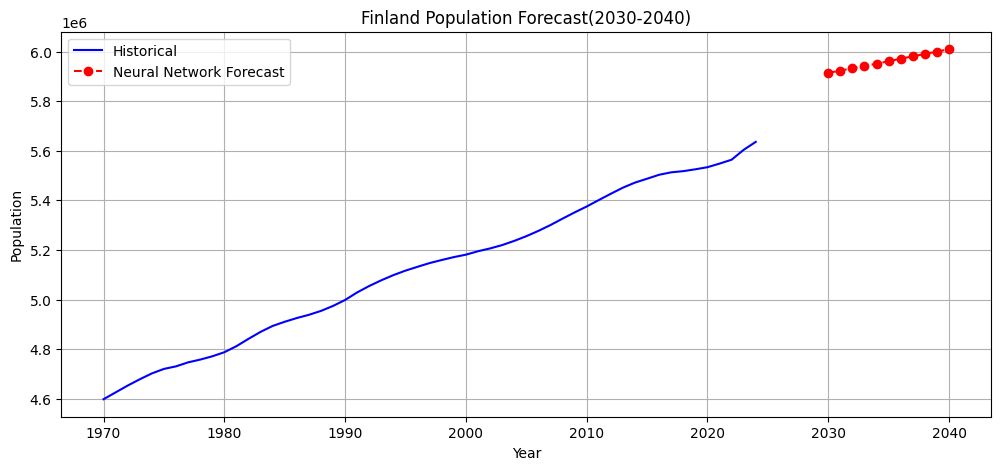

In [10]:
# Prepare features and target
X = df[['Year', 'Net migration', 'Natural increase']].values
y = df['Population'].values

# Split into train/test
train_size = len(df[df['Year'] <= 2014])
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Scale target too
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

# Build neural network
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3,)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation="linear")
])

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss="mse",
    metrics=["mae"]
)

# Early stopping
callback = tf.keras.callbacks.EarlyStopping(
    patience=20,
    restore_best_weights=True
)

# Train
history = model.fit(
    X_train_scaled, y_train_scaled,
    epochs=200,
    validation_split=0.2,
    callbacks=[callback],
    verbose=1
)

# Evaluate
loss, mae = model.evaluate(X_test_scaled, y_test_scaled, verbose=0)
print(f"Test MAE (scaled): {mae:.3f}")

# Predict
future_years = np.arange(2030, 2041)

avg_migration = df[df['Year'] >= 2020]['Net migration'].mean()
avg_natural = df[df['Year'] >= 2020]['Natural increase'].mean()

X_future = np.column_stack([future_years, 
                            [avg_migration] * len(future_years),
                            [avg_natural] * len(future_years)])
X_future_scaled = scaler.transform(X_future)
future_pred_scaled = model.predict(X_future_scaled, verbose=0)
future_pred = scaler_y.inverse_transform(future_pred_scaled)

# Results
print("\n=== FORECAST 2030-2040 ===")
for year, pop in zip(future_years, future_pred.flatten()):
    print(f"{year}: {pop:,.0f}")

#  --- Plot ---
plt.figure(figsize=(12,5))
plt.plot(df['Year'], df['Population'], label='Historical', color='blue')
plt.plot(future_years, future_pred, 'r--o', label='Neural Network Forecast')
plt.xlabel('Year')
plt.ylabel('Population')
plt.title('Finland Population Forecast(2030-2040)')
plt.legend()
plt.grid(True)
plt.show()

## 2. run
I have added **lag feature**. It is values from previous year, in my case:</br> 
- `population_lag1` is year ago 
- `population_lad2` is two years ago. 
</br>
This feature is nessesary because predictions strongly depens on the data from previous years and relationship between them.</br> 
This feature allows model to understant it. It prevends model from treating each year independently.

I decided to make predictions from 2025 - 2040, because that way it will be easier for model to understand relationship

I also updated prediction methode. Now model uses lag feature. So when it predicts population for 2027 year, it then uses this prediction to predict 2028 and so on.</br> 
This approuche allows model to simulate how population evolves over time. 

### Result
Model works, but backtest is bad and prediction is even worse.

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 149ms/step - loss: 0.8387 - mae: 0.7475 - val_loss: 2.7989 - val_mae: 1.6678
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.4774 - mae: 0.5652 - val_loss: 1.5892 - val_mae: 1.2603
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.3092 - mae: 0.4415 - val_loss: 0.4975 - val_mae: 0.6831
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.1735 - mae: 0.3156 - val_loss: 0.2301 - val_mae: 0.3586
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0372 - mae: 0.1447 - val_loss: 2.4304 - val_mae: 1.3780
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0439 - mae: 0.1710 - val_loss: 4.6627 - val_mae: 1.9640
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0917 - mae: 0.2159 - val_loss: 3.3354 - val_mae: 1.6304
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0500 - mae: 0.1754 - val_loss: 1.5212 - val_mae: 1.0332
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0132 - mae:

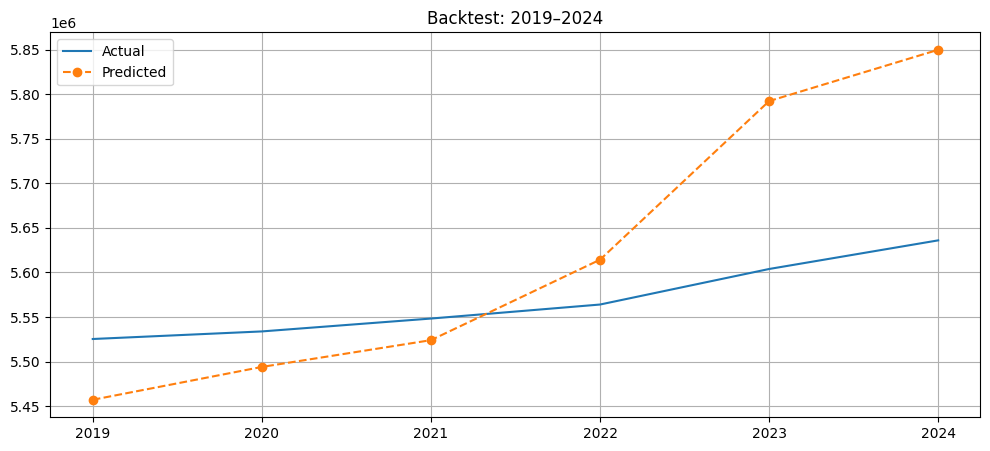

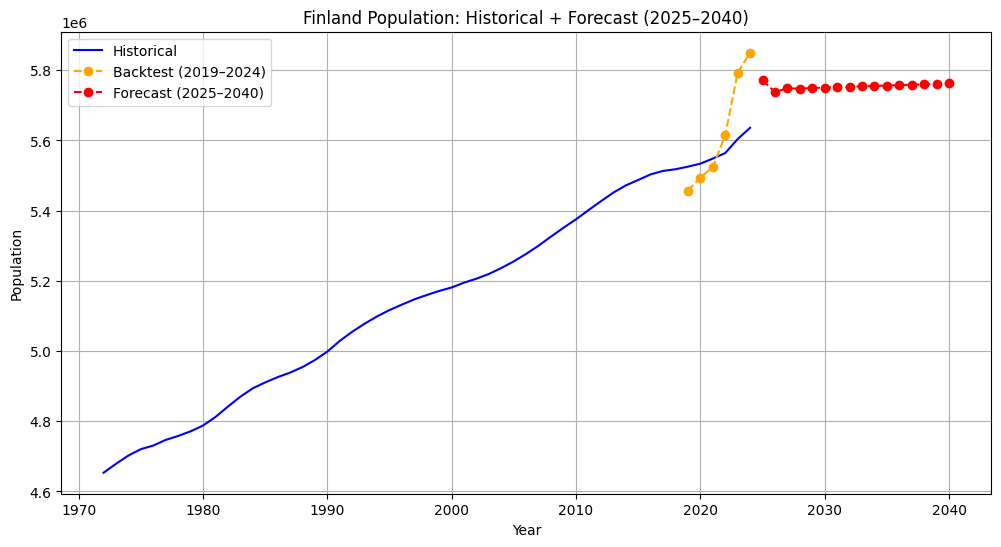

In [11]:
df['Population_lag1'] = df['Population'].shift(1)
df['Population_lag2'] = df['Population'].shift(2)
df['Migration_lag1'] = df['Net migration'].shift(1)
df['Natural_lag1'] = df['Natural increase'].shift(1)

df = df.dropna().reset_index(drop=True)

features = [
    'Year',
    'Net migration',
    'Natural increase',
    'Population_lag1',
    'Population_lag2',
    'Migration_lag1',
    'Natural_lag1'
]

X = df[features].values
y = df['Population'].values

# Split into train/test
df_train = df[df['Year'] <= 2018]
df_test = df[(df['Year'] > 2018) & (df['Year'] <= 2024)]

X_train = df_train[features].values
X_test = df_test[features].values
y_train = df_train['Population'].values
y_test = df_test['Population'].values

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Scale target too
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()

# Build neural network
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(len(features),)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation="linear")
])

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss="mse",
    metrics=["mae"]
)

# Early stopping
callback = tf.keras.callbacks.EarlyStopping(
    patience=20,
    restore_best_weights=True
)

# Train
history = model.fit(
    X_train_scaled, 
    y_train_scaled,
    epochs=200,
    validation_data=(X_test_scaled, scaler_y.transform(y_test.reshape(-1,1)).flatten()),
    callbacks=[callback],
    verbose=1
)

# Predict on test set
y_pred_scaled = model.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

# Predict
future_years = np.arange(2025, 2041)

avg_migration = df[df['Year'] >= 2020]['Net migration'].mean()
avg_natural = df[df['Year'] >= 2020]['Natural increase'].mean()

last_row = df[df['Year'] == 2024].iloc[0]
prev_row = df[df['Year'] == 2023].iloc[0]

current_pop_lag1 = last_row['Population']
current_pop_lag2 = prev_row['Population']

current_migration_lag1 = last_row['Net migration']
current_natural_lag1 = last_row['Natural increase']

future_pred = []

for year in future_years:

    migration = avg_migration
    natural = avg_natural

    X_input = np.array([[
        year,
        migration,
        natural,
        current_pop_lag1,
        current_pop_lag2,
        current_migration_lag1,
        current_natural_lag1
    ]])

    X_scaled = scaler.transform(X_input)

    pred_scaled = model.predict(X_scaled, verbose=0)
    pred = scaler_y.inverse_transform(pred_scaled)[0][0]

    future_pred.append(pred)

    current_pop_lag2 = current_pop_lag1
    current_pop_lag1 = pred
    current_migration_lag1 = migration
    current_natural_lag1 = natural


# Results
future_pred = np.array(future_pred)

print("\n=== FORECAST 2030-2040 ===")
for year, pop in zip(future_years, future_pred.flatten()):
    print(f"{year}: {pop:,.0f}")

#  --- Plot backtest---
plt.figure(figsize=(12,5))
plt.plot(df_test['Year'], y_test, label='Actual')
plt.plot(df_test['Year'], y_pred, '--o', label='Predicted')
plt.title('Backtest: 2019–2024')
plt.legend()
plt.grid(True)
plt.show()

# --- Plot forecast ---
plt.figure(figsize=(12,6))
plt.plot(df['Year'], df['Population'], label='Historical', color='blue')
plt.plot(df_test['Year'], y_pred, '--o', label='Backtest (2019–2024)', color='orange')
plt.plot(future_years, future_pred, 'r--o', label='Forecast (2025–2040)')
plt.xlabel('Year')
plt.ylabel('Population')
plt.title('Finland Population: Historical + Forecast (2025–2040)')
plt.legend()
plt.grid(True)
plt.show()

## 3. Run
I decided to add delta prediction approach. Idea is that model will predict yearly change in population (delta population) instead of absolut population value. Then population from previous year will be added to the predicted change in population to get population for specific year.</br>
Formula looks like this: **Population(t) = Population(t-1) + Predicted Delta**


### Result
backtest data is very good, I hope it is not overfitting. But forecast plot looks very good too, but it is too straight. I think that is due to small amount of data. I use only years, net nuigration and natural increase.<br> 
Next big step will be adding dataset with age!

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step - loss: 1.1076 - mae: 0.8871 - val_loss: 4.0076 - val_mae: 1.4114
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.6467 - mae: 0.6686 - val_loss: 2.3561 - val_mae: 1.0611
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.3511 - mae: 0.4757 - val_loss: 0.5902 - val_mae: 0.4832
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.2443 - mae: 0.4093 - val_loss: 6.4139 - val_mae: 2.4207
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.2197 - mae: 0.3263 - val_loss: 3.5896 - val_mae: 1.7457
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.1602 - mae: 0.3145 - val_loss: 0.8246 - val_mae: 0.8537
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.1414 - mae: 0.3080 - val_loss: 1.2000 - val_mae: 0.9581
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0943 - mae: 0.2299 - val_loss: 1.5087 - val_mae: 1.0218
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0714 - mae:

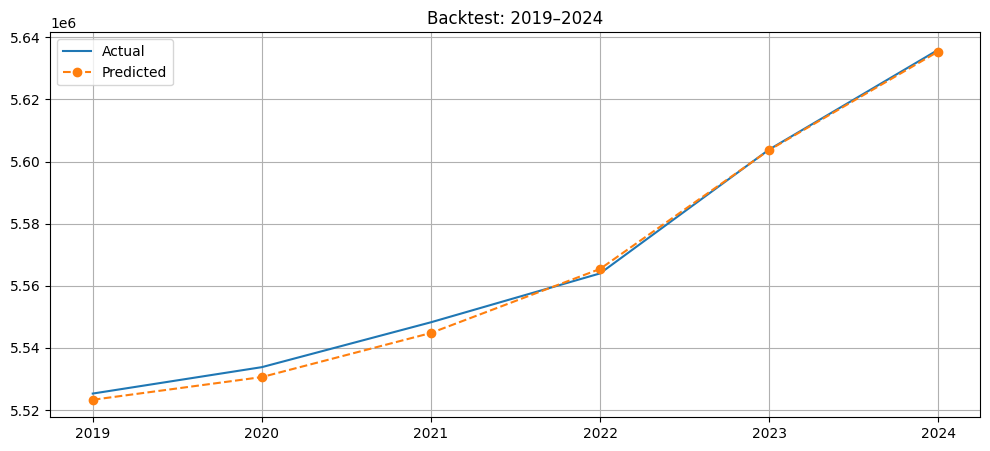

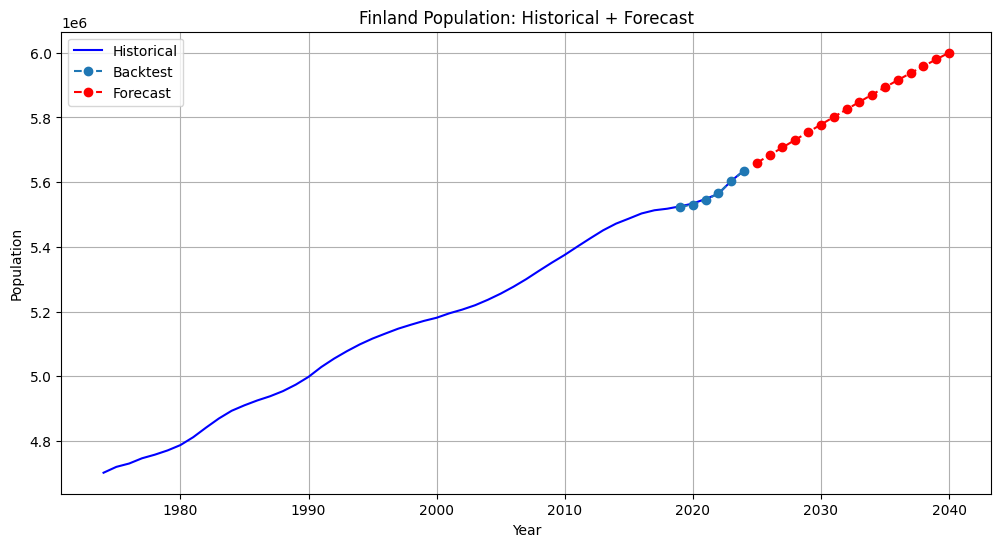

In [12]:
# FEATURES + TARGET
df['Population_lag1'] = df['Population'].shift(1)
df['Population_lag2'] = df['Population'].shift(2)
df['Migration_lag1'] = df['Net migration'].shift(1)
df['Natural_lag1'] = df['Natural increase'].shift(1)

df['Population_delta'] = df['Population'].diff()

df = df.dropna().reset_index(drop=True)

features = [
    'Year',
    'Net migration',
    'Natural increase',
    'Population_lag1',
    'Population_lag2',
    'Migration_lag1',
    'Natural_lag1'
]

X = df[features].values
y = df['Population_delta'].values


# SPLIT
df_train = df[df['Year'] <= 2018]
df_test = df[(df['Year'] > 2018) & (df['Year'] <= 2024)]

X_train = df_train[features].values
X_test = df_test[features].values
y_train = df_train['Population_delta'].values
y_test = df_test['Population_delta'].values


# SCALING
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))


# MODEL
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(len(features),)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss="mse",
    metrics=["mae"]
)

callback = tf.keras.callbacks.EarlyStopping(
    patience=20,
    restore_best_weights=True
)


# TRAIN
history = model.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=200,
    validation_data=(X_test_scaled, y_test_scaled),
    callbacks=[callback],
    verbose=1
)


# BACKTEST
y_pred_scaled = model.predict(X_test_scaled)

y_pred_delta = scaler_y.inverse_transform(y_pred_scaled).flatten()

test_df = df_test.copy()

reconstructed = []
current_pop = df.loc[df['Year'] == 2018, 'Population'].values[0]

for delta in y_pred_delta:
    current_pop += delta
    reconstructed.append(current_pop)

y_test_real = test_df['Population'].values


# EVALUATION
mae = mean_absolute_error(y_test_real, reconstructed)
print("MAE:", mae)


# FORECAST
future_years = np.arange(2025, 2041)

avg_migration = df['Net migration'].tail(5).mean()
avg_natural = df['Natural increase'].tail(5).mean()

last_row = df[df['Year'] == 2024].iloc[0]
prev_row = df[df['Year'] == 2023].iloc[0]

current_population = last_row['Population']

current_pop_lag1 = last_row['Population']
current_pop_lag2 = prev_row['Population']
current_migration_lag1 = last_row['Net migration']
current_natural_lag1 = last_row['Natural increase']

future_pred = []

for year in future_years:

    X_input = np.array([[
        year,
        avg_migration,
        avg_natural,
        current_pop_lag1,
        current_pop_lag2,
        current_migration_lag1,
        current_natural_lag1
    ]])

    X_scaled = scaler.transform(X_input)

    delta_scaled = model.predict(X_scaled, verbose=0)
    delta = scaler_y.inverse_transform(delta_scaled)[0][0]

    current_population += delta
    future_pred.append(current_population)

    current_pop_lag2 = current_pop_lag1
    current_pop_lag1 = current_population
    current_migration_lag1 = avg_migration
    current_natural_lag1 = avg_natural

future_pred = np.array(future_pred)


# PRINT RESULTS
print("\n=== FORECAST 2025–2040 ===")
for year, pop in zip(future_years, future_pred):
    print(f"{year}: {pop:,.0f}")


# PLOTS
plt.figure(figsize=(12,5))
plt.plot(df_test['Year'], y_test_real, label='Actual')
plt.plot(df_test['Year'], reconstructed, '--o', label='Predicted')
plt.title('Backtest: 2019–2024')
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(12,6))
plt.plot(df['Year'], df['Population'], label='Historical', color='blue')
plt.plot(df_test['Year'], reconstructed, '--o', label='Backtest')
plt.plot(future_years, future_pred, 'r--o', label='Forecast')
plt.xlabel('Year')
plt.ylabel('Population')
plt.title('Finland Population: Historical + Forecast')
plt.legend()
plt.grid(True)
plt.show()

### 4. Run

This version of the model I have added one more dataset with age of Finnish population by years.</br>
Data is splited into three age groups:</br>
- Youth
- Working age
- Elderly

Each group is treated as separarte feature.</br>
This upgrate is big because now model can learn:
- how population ages
- death rates vary by age
- migration impact is different


Epoch 1/200


C:\Users\rolan\AppData\Local\Temp\ipykernel_1604\1302690141.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Youth"] = df[age_cols[0:20]].sum(axis=1)
C:\Users\rolan\AppData\Local\Temp\ipykernel_1604\1302690141.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Working_Age"] = df[age_cols[20:65]].sum(axis=1)
C:\Users\rolan\AppData\Local\Temp\ipykernel_1604\1302690141.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - loss: 1.0550 - mae: 0.8751 - val_loss: 6.7680 - val_mae: 1.8801
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.7835 - mae: 0.7504 - val_loss: 5.9610 - val_mae: 1.7366
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.6667 - mae: 0.6862 - val_loss: 5.4845 - val_mae: 1.6473
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.5305 - mae: 0.6000 - val_loss: 6.1256 - val_mae: 1.7226
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.4225 - mae: 0.5288 - val_loss: 6.2723 - val_mae: 1.7691
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.3141 - mae: 0.4529 - val_loss: 6.1874 - val_mae: 1.9259
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.2077 - mae: 0.3524 - val_loss: 5.5517 - val_mae: 1.9312
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.1590 - mae: 0.3023 - val_loss: 4.7140 - val_mae: 1.8410
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.1362 - mae: 0.2845 - va

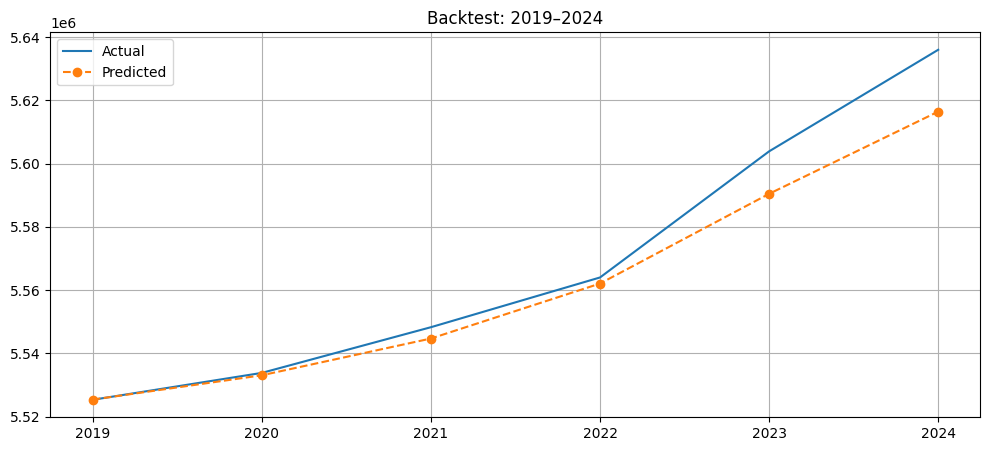

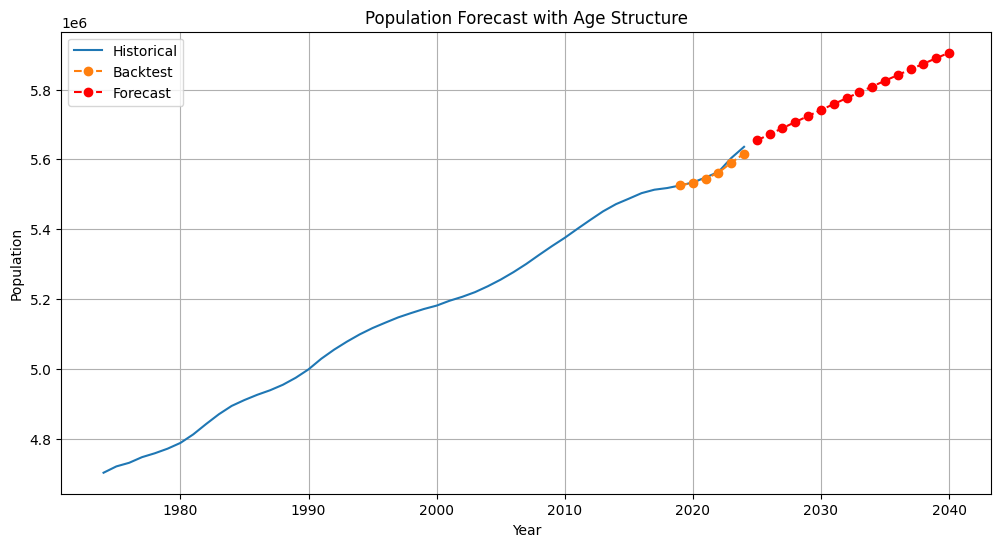


=== FORECAST 2025–2040 ===
2025: 5,654,158
2026: 5,671,916
2027: 5,689,518
2028: 5,706,969
2029: 5,724,269
2030: 5,741,420
2031: 5,758,422
2032: 5,775,301
2033: 5,792,060
2034: 5,808,699
2035: 5,825,219
2036: 5,841,612
2037: 5,857,840
2038: 5,873,904
2039: 5,889,805
2040: 5,905,544


In [13]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error


df_main = pd.read_csv("dataset.csv")
df_age = pd.read_csv("age_data.csv")

df = df_main.merge(df_age, on="Year", how="inner")


# 1. PREPARE DATA
df = df.sort_values("Year").reset_index(drop=True)

age_cols = [col for col in df.columns if "Population 31 Dec" in col]

age_cols = sorted(age_cols, key=lambda x: int(x.split()[0]))

df["Youth"] = df[age_cols[0:20]].sum(axis=1)
df["Working_Age"] = df[age_cols[20:65]].sum(axis=1)
df["Elderly"] = df[age_cols[65:]].sum(axis=1)


df["Dependency_ratio"] = df["Elderly"] / df["Working_Age"]


# 2. FEATURE ENGINEERING
df["Population_lag1"] = df["Population"].shift(1)
df["Population_lag2"] = df["Population"].shift(2)

df["Migration_lag1"] = df["Net migration"].shift(1)
df["Natural_lag1"] = df["Natural increase"].shift(1)

# Target = delta
df["Population_delta"] = df["Population"].diff()

df = df.dropna().reset_index(drop=True)



# 3. FEATURES / TARGET
features = [
    'Year',
    'Net migration',
    'Natural increase',
    'Population_lag1',
    'Population_lag2',
    'Migration_lag1',
    'Natural_lag1',
    'Youth',
    'Working_Age',
    'Elderly',
    'Dependency_ratio'
]

X = df[features].values
y = df["Population_delta"].values



# 4. TRAIN / TEST SPLIT
df_train = df[df["Year"] <= 2018]
df_test = df[(df["Year"] > 2018) & (df["Year"] <= 2024)]

X_train = df_train[features].values
X_test = df_test[features].values

y_train = df_train["Population_delta"].values
y_test = df_test["Population_delta"].values



# 5. SCALING
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))



# 6. MODEL
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(len(features),)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    loss="mse",
    metrics=["mae"]
)

callback = tf.keras.callbacks.EarlyStopping(
    patience=20,
    restore_best_weights=True
)


# 7. TRAIN
history = model.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=200,
    validation_data=(X_test_scaled, y_test_scaled),
    callbacks=[callback],
    verbose=1
)


# 8. BACKTEST (2019–2024)
y_pred_scaled = model.predict(X_test_scaled)
y_pred_delta = scaler_y.inverse_transform(y_pred_scaled).flatten()

reconstructed = []
current_pop = df.loc[df["Year"] == 2018, "Population"].values[0]

for delta in y_pred_delta:
    current_pop += delta
    reconstructed.append(current_pop)

y_test_real = df_test["Population"].values

mae = mean_absolute_error(y_test_real, reconstructed)
print("MAE:", mae)


# 9. FORECAST 2025–2040
future_years = np.arange(2025, 2041)

last = df[df["Year"] == 2024].iloc[0]
prev = df[df["Year"] == 2023].iloc[0]

current_population = last["Population"]

pop_lag1 = last["Population"]
pop_lag2 = prev["Population"]

migration_lag1 = last["Net migration"]
natural_lag1 = last["Natural increase"]

youth = last["Youth"]
working = last["Working_Age"]
elderly = last["Elderly"]
dep_ratio = last["Dependency_ratio"]

avg_migration = df["Net migration"].tail(5).mean()
avg_natural = df["Natural increase"].tail(5).mean()

future_pred = []

for year in future_years:

    X_input = np.array([[  
        year,
        avg_migration,
        avg_natural,
        pop_lag1,
        pop_lag2,
        migration_lag1,
        natural_lag1,
        youth,
        working,
        elderly,
        dep_ratio
    ]])

    X_scaled = scaler_X.transform(X_input)

    delta_scaled = model.predict(X_scaled, verbose=0)
    delta = scaler_y.inverse_transform(delta_scaled)[0][0]

    current_population += delta
    future_pred.append(current_population)

    pop_lag2 = pop_lag1
    pop_lag1 = current_population
    migration_lag1 = avg_migration
    natural_lag1 = avg_natural

future_pred = np.array(future_pred)


# 10. PLOTS
plt.figure(figsize=(12,5))
plt.plot(df_test["Year"], y_test_real, label="Actual")
plt.plot(df_test["Year"], reconstructed, "--o", label="Predicted")
plt.title("Backtest: 2019–2024")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,6))
plt.plot(df["Year"], df["Population"], label="Historical")
plt.plot(df_test["Year"], reconstructed, "--o", label="Backtest")
plt.plot(future_years, future_pred, "r--o", label="Forecast")
plt.xlabel("Year")
plt.ylabel("Population")
plt.title("Population Forecast with Age Structure")
plt.legend()
plt.grid(True)
plt.show()


# 11. PRINT FORECAST
print("\n=== FORECAST 2025–2040 ===")
for y, p in zip(future_years, future_pred):
    print(f"{y}: {p:,.0f}")

### 5. Run
To make model even better I have added **dynamic age change**</br>
So model can learn:
- population ages
- there is changes in structure of population, for example more young people who give birth

In the future natural increase can become possitive again 

Epoch 1/200


C:\Users\rolan\AppData\Local\Temp\ipykernel_1604\3702424412.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Youth"] = df[age_cols[0:20]].sum(axis=1)
C:\Users\rolan\AppData\Local\Temp\ipykernel_1604\3702424412.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Working_Age"] = df[age_cols[20:65]].sum(axis=1)
C:\Users\rolan\AppData\Local\Temp\ipykernel_1604\3702424412.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - loss: 1.0904 - mae: 0.8753 - val_loss: 2.8584 - val_mae: 1.5813
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.8157 - mae: 0.7765 - val_loss: 3.4509 - val_mae: 1.2978
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.6686 - mae: 0.6970 - val_loss: 3.6589 - val_mae: 1.2761
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.5215 - mae: 0.6153 - val_loss: 2.2786 - val_mae: 0.9501
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.3389 - mae: 0.4909 - val_loss: 1.0226 - val_mae: 0.6796
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.2266 - mae: 0.3857 - val_loss: 0.6034 - val_mae: 0.4815
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.1303 - mae: 0.2868 - val_loss: 1.0472 - val_mae: 0.8699
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.1000 - mae: 0.2376 - val_loss: 0.8395 - val_mae: 0.8035
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0879 - mae: 0.2112 - va

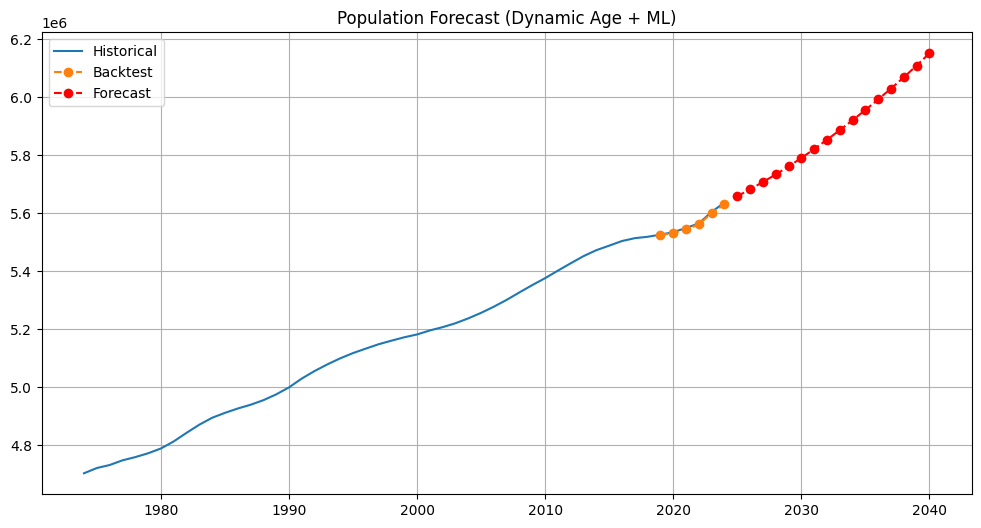


=== FORECAST 2025–2040 ===
2025: 5,657,671
2026: 5,681,660
2027: 5,706,665
2028: 5,732,773
2029: 5,760,317
2030: 5,789,484
2031: 5,820,338
2032: 5,852,377
2033: 5,885,551
2034: 5,919,876
2035: 5,955,210
2036: 5,991,593
2037: 6,029,135
2038: 6,067,865
2039: 6,108,373
2040: 6,150,628


In [14]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error


# 1. LOAD + MERGE DATA
df_main = pd.read_csv("dataset.csv")
df_age = pd.read_csv("age_data.csv")

df = df_main.merge(df_age, on="Year", how="inner")
df = df.sort_values("Year").reset_index(drop=True)


# 2. AGE COLUMNS
age_cols = [col for col in df.columns if "Population 31 Dec" in col]
age_cols = sorted(age_cols, key=lambda x: int(x.split()[0]))



# 3. COMPRESS AGE STRUCTURE
df["Youth"] = df[age_cols[0:20]].sum(axis=1)
df["Working_Age"] = df[age_cols[20:65]].sum(axis=1)
df["Elderly"] = df[age_cols[65:]].sum(axis=1)

df["Dependency_ratio"] = df["Elderly"] / df["Working_Age"]


# 4. FEATURE ENGINEERING
df["Population_lag1"] = df["Population"].shift(1)
df["Population_lag2"] = df["Population"].shift(2)

df["Migration_lag1"] = df["Net migration"].shift(1)
df["Natural_lag1"] = df["Natural increase"].shift(1)

df["Population_delta"] = df["Population"].diff()

df = df.dropna().reset_index(drop=True)


# 5. FEATURES / TARGET
features = [
    'Year',
    'Net migration',
    'Natural increase',
    'Population_lag1',
    'Population_lag2',
    'Migration_lag1',
    'Natural_lag1',
    'Youth',
    'Working_Age',
    'Elderly',
    'Dependency_ratio'
]


# 6. TRAIN / TEST SPLIT
df_train = df[df["Year"] <= 2018]
df_test = df[(df["Year"] > 2018) & (df["Year"] <= 2024)]

X_train = df_train[features].values
X_test = df_test[features].values

y_train = df_train["Population_delta"].values
y_test = df_test["Population_delta"].values



# 7. SCALING
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))


# 8. MODEL
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(len(features),)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    loss="mse",
    metrics=["mae"]
)

callback = tf.keras.callbacks.EarlyStopping(
    patience=20,
    restore_best_weights=True
)

# 9. TRAIN
model.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=200,
    validation_data=(X_test_scaled, y_test_scaled),
    callbacks=[callback],
    verbose=1
)


# 10. BACKTEST
y_pred_scaled = model.predict(X_test_scaled)
y_pred_delta = scaler_y.inverse_transform(y_pred_scaled).flatten()

reconstructed = []
current_pop = df.loc[df["Year"] == 2018, "Population"].values[0]

for delta in y_pred_delta:
    current_pop += delta
    reconstructed.append(current_pop)

mae = mean_absolute_error(df_test["Population"], reconstructed)
print("MAE:", mae)


# 11. AGE MODEL SETUP
ages = np.arange(len(age_cols))
age_state = df[df["Year"] == 2024][age_cols].values[0].astype(float)

mortality_rate = np.zeros(len(ages))
for age in ages:
    if age < 1:
        mortality_rate[age] = 0.003
    elif age < 15:
        mortality_rate[age] = 0.0005
    elif age < 40:
        mortality_rate[age] = 0.001
    elif age < 65:
        mortality_rate[age] = 0.005
    elif age < 80:
        mortality_rate[age] = 0.02
    else:
        mortality_rate[age] = 0.08

fertility_rate = np.zeros(len(ages))
for age in range(15, 50):
    fertility_rate[age] = 0.04

avg_migration = df["Net migration"].tail(5).mean()
avg_natural = df["Natural increase"].tail(5).mean()

migration = np.zeros(len(ages))
migration[20:45] = avg_migration / 25

def simulate_year(state):
    new_state = np.zeros_like(state)

    for age in range(len(state) - 1, 0, -1):
        new_state[age] = state[age - 1] * (1 - mortality_rate[age - 1])

    births = np.sum(state * fertility_rate)
    new_state[0] = births

    new_state += migration

    return new_state


# 12. FORECAST (DYNAMIC AGE)
future_years = np.arange(2025, 2041)

last = df[df["Year"] == 2024].iloc[0]
prev = df[df["Year"] == 2023].iloc[0]

current_population = last["Population"]

pop_lag1 = last["Population"]
pop_lag2 = prev["Population"]

migration_lag1 = last["Net migration"]
natural_lag1 = last["Natural increase"]

current_state = age_state.copy()

future_pred = []

for year in future_years:
    current_state = simulate_year(current_state)

    youth = np.sum(current_state[0:20])
    working = np.sum(current_state[20:65])
    elderly = np.sum(current_state[65:])
    dep_ratio = elderly / working if working > 0 else 0

    X_input = np.array([[  
        year,
        avg_migration,
        avg_natural,
        pop_lag1,
        pop_lag2,
        migration_lag1,
        natural_lag1,
        youth,
        working,
        elderly,
        dep_ratio
    ]])

    X_scaled = scaler_X.transform(X_input)

    delta_scaled = model.predict(X_scaled, verbose=0)
    delta = scaler_y.inverse_transform(delta_scaled)[0][0]

    current_population += delta
    future_pred.append(current_population)

    pop_lag2 = pop_lag1
    pop_lag1 = current_population
    migration_lag1 = avg_migration
    natural_lag1 = avg_natural

future_pred = np.array(future_pred)


# 13. PLOTS
plt.figure(figsize=(12,6))
plt.plot(df["Year"], df["Population"], label="Historical")
plt.plot(df_test["Year"], reconstructed, "--o", label="Backtest")
plt.plot(future_years, future_pred, "r--o", label="Forecast")
plt.legend()
plt.grid(True)
plt.title("Population Forecast (Dynamic Age + ML)")
plt.show()


# 14. OUTPUT
print("\n=== FORECAST 2025–2040 ===")
for y, p in zip(future_years, future_pred):
    print(f"{y}: {p:,.0f}")

Last model works fine, but I have noticed that even tho I make big changes like adding age groups, dynamic age, etc.</br>
Results doesn't change a lot, thats because first features that I implemented:
- population_lag
- migration is static
- natural increase is static

This features give too big affect on the model, because of that even after adding age groups model doesn't rely on it.</br>
I am interested what results I will get if I will:
- delete `lag feature`
- make `migration` trend based
- make `natural change`: births - deaths

This should make model behave more realisticly


C:\Users\rolan\AppData\Local\Temp\ipykernel_1604\649324329.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Births"] = df["Live births"]


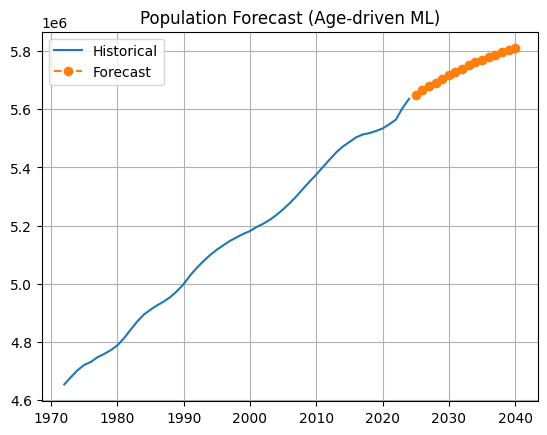


=== FORECAST ===
2025: 5,650,808
2026: 5,665,657
2027: 5,679,299
2028: 5,691,863
2029: 5,704,231
2030: 5,716,601
2031: 5,728,742
2032: 5,740,229
2033: 5,750,933
2034: 5,761,162
2035: 5,770,927
2036: 5,779,982
2037: 5,788,285
2038: 5,795,986
2039: 5,802,961
2040: 5,809,119


In [15]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression


# 1. LOAD DATA
df_main = pd.read_csv("dataset.csv")
df_age = pd.read_csv("age_data.csv")

df = df_main.merge(df_age, on="Year", how="inner")
df = df.sort_values("Year").reset_index(drop=True)


# 2. AGE FEATURES
age_cols = [c for c in df.columns if "Population 31 Dec" in c]
age_cols = sorted(age_cols, key=lambda x: int(x.split()[0]))

age_features = pd.DataFrame({
    "Youth": df[age_cols[0:20]].sum(axis=1),
    "Working_Age": df[age_cols[20:65]].sum(axis=1),
    "Elderly": df[age_cols[65:]].sum(axis=1),
})

age_features["Dependency_ratio"] = age_features["Elderly"] / age_features["Working_Age"]

df = pd.concat([df, age_features], axis=1)


# 3. TARGETS
df["Births"] = df["Live births"]
df["Deaths"] = df["Deaths"]


# 4. FEATURES (NO LAGS)
features = [
    "Year",
    "Youth",
    "Working_Age",
    "Elderly",
    "Dependency_ratio"
]


# 5. TRAIN SPLIT
df_train = df[df["Year"] <= 2018]
df_test = df[df["Year"] > 2018]

X_train = df_train[features].values
X_test = df_test[features].values

y_birth_train = df_train["Births"].values
y_death_train = df_train["Deaths"].values



# 6. SCALING
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)

scaler_birth = StandardScaler()
y_birth_scaled = scaler_birth.fit_transform(y_birth_train.reshape(-1,1))

scaler_death = StandardScaler()
y_death_scaled = scaler_death.fit_transform(y_death_train.reshape(-1,1))



# 7. MODELS
def build_model():
    m = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(len(features),)),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(1)
    ])
    m.compile(optimizer="adam", loss="mse")
    return m

model_birth = build_model()
model_death = build_model()



# 8. TRAIN
model_birth.fit(X_train_scaled, y_birth_scaled, epochs=150, verbose=0)
model_death.fit(X_train_scaled, y_death_scaled, epochs=150, verbose=0)


# 9. MIGRATION TREND MODEL
trend_model = LinearRegression()
trend_model.fit(df[["Year"]], df["Net migration"])



# 10. AGE DYNAMICS SETUP
ages = np.arange(len(age_cols))
state = df[df["Year"] == 2024][age_cols].values[0].astype(float)

mortality_rate = np.zeros(len(ages))
for age in ages:
    if age < 1:
        mortality_rate[age] = 0.003
    elif age < 15:
        mortality_rate[age] = 0.0005
    elif age < 40:
        mortality_rate[age] = 0.001
    elif age < 65:
        mortality_rate[age] = 0.005
    elif age < 80:
        mortality_rate[age] = 0.02
    else:
        mortality_rate[age] = 0.08

def simulate_year(state):
    new = np.zeros_like(state)

    for age in range(len(state)-1,0,-1):
        new[age] = state[age-1]*(1-mortality_rate[age-1])

    return new



# 11. FORECAST
years = np.arange(2025, 2041)
population = df[df["Year"]==2024]["Population"].values[0]

future_pop = []
current_state = state.copy()

for year in years:

    current_state = simulate_year(current_state)

    youth = np.sum(current_state[0:20])
    working = np.sum(current_state[20:65])
    elderly = np.sum(current_state[65:])
    dep = elderly / working if working > 0 else 0

    X_input = scaler_X.transform([[year, youth, working, elderly, dep]])

    births = scaler_birth.inverse_transform(
        model_birth.predict(X_input, verbose=0)
    )[0][0]

    deaths = scaler_death.inverse_transform(
        model_death.predict(X_input, verbose=0)
    )[0][0]

    migration = trend_model.predict(pd.DataFrame({"Year": [year]}))[0]

    population = population + births - deaths + migration
    future_pop.append(population)



# 12. RESULTS
plt.plot(df["Year"], df["Population"], label="Historical")
plt.plot(years, future_pop, "--o", label="Forecast")
plt.legend()
plt.grid()
plt.title("Population Forecast (Age-driven ML)")
plt.show()

print("\n=== FORECAST ===")
for y, p in zip(years, future_pop):
    print(f"{y}: {p:,.0f}")

### Model for supercomputer

C:\Users\rolan\AppData\Local\Temp\ipykernel_24512\714426137.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Youth"] = df[age_cols[0:20]].sum(axis=1)
C:\Users\rolan\AppData\Local\Temp\ipykernel_24512\714426137.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Working_Age"] = df[age_cols[20:65]].sum(axis=1)
C:\Users\rolan\AppData\Local\Temp\ipykernel_24512\714426137.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance

Training ensemble of 15 big models...

Training model 1/15...
  Model 1 done. Best val MAE: 1.5814

Training model 2/15...
  Model 2 done. Best val MAE: 1.7393

Training model 3/15...
  Model 3 done. Best val MAE: 1.4989

Training model 4/15...
  Model 4 done. Best val MAE: 1.4933

Training model 5/15...
  Model 5 done. Best val MAE: 1.5461

Training model 6/15...
  Model 6 done. Best val MAE: 1.7443

Training model 7/15...
  Model 7 done. Best val MAE: 1.6397

Training model 8/15...
  Model 8 done. Best val MAE: 1.5196

Training model 9/15...
  Model 9 done. Best val MAE: 1.5840

Training model 10/15...
  Model 10 done. Best val MAE: 1.7408

Training model 11/15...
  Model 11 done. Best val MAE: 1.6581

Training model 12/15...
  Model 12 done. Best val MAE: 1.5535

Training model 13/15...
  Model 13 done. Best val MAE: 1.6775

Training model 14/15...
  Model 14 done. Best val MAE: 1.6958

Training model 15/15...
  Model 15 done. Best val MAE: 1.4280

Training mega-model (best architec

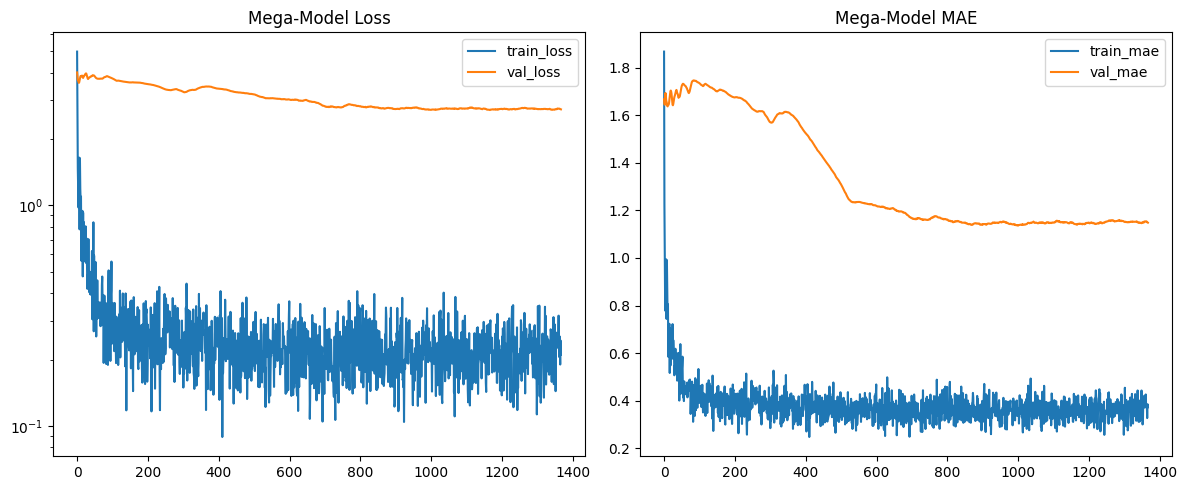

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step

MAE (Ensemble): 17,105
MAE (Mega-Model): 12,700

Using Mega-Model for forecasting (better MAE)


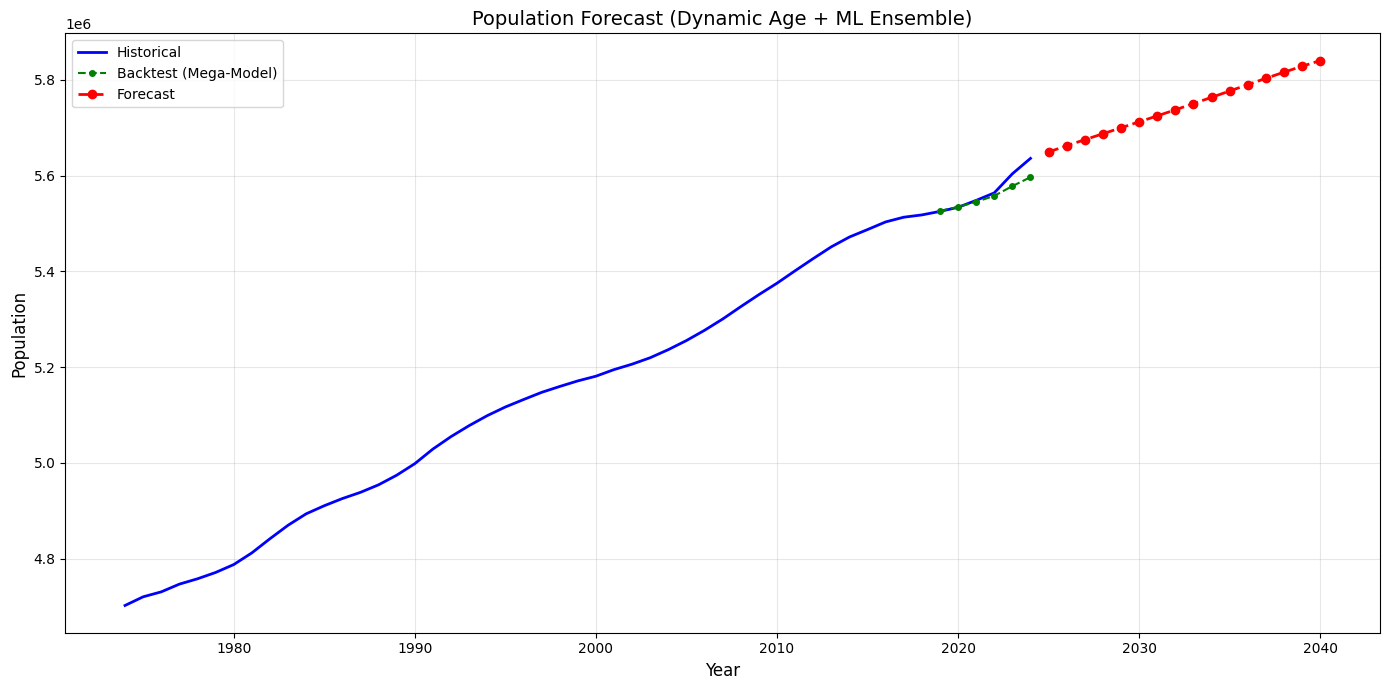


FORECAST 2025–2040 (using MEGA-MODEL)
Year       Population      Lower 95%       Upper 95%      
------------------------------------------------------------
2025          5,649,328            N/A            N/A
2026          5,662,385            N/A            N/A
2027          5,675,012            N/A            N/A
2028          5,687,437            N/A            N/A
2029          5,699,860            N/A            N/A
2030          5,712,295            N/A            N/A
2031          5,724,737            N/A            N/A
2032          5,737,423            N/A            N/A
2033          5,750,422            N/A            N/A
2034          5,763,456            N/A            N/A
2035          5,776,672            N/A            N/A
2036          5,789,932            N/A            N/A
2037          5,803,137            N/A            N/A
2038          5,816,012            N/A            N/A
2039          5,828,373            N/A            N/A
2040          5,840,205        

In [5]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error


# 1. LOAD + MERGE DATA
df_main = pd.read_csv("dataset.csv")
df_age = pd.read_csv("age_data.csv")

df = df_main.merge(df_age, on="Year", how="inner")
df = df.sort_values("Year").reset_index(drop=True)


# 2. AGE COLUMNS
age_cols = [col for col in df.columns if "Population 31 Dec" in col]
age_cols = sorted(age_cols, key=lambda x: int(x.split()[0]))


# 3. COMPRESS AGE STRUCTURE
df["Youth"] = df[age_cols[0:20]].sum(axis=1)
df["Working_Age"] = df[age_cols[20:65]].sum(axis=1)
df["Elderly"] = df[age_cols[65:]].sum(axis=1)

df["Dependency_ratio"] = df["Elderly"] / df["Working_Age"]


# 4. FEATURE ENGINEERING
df["Population_lag1"] = df["Population"].shift(1)
df["Population_lag2"] = df["Population"].shift(2)

df["Migration_lag1"] = df["Net migration"].shift(1)
df["Natural_lag1"] = df["Natural increase"].shift(1)

df["Population_delta"] = df["Population"].diff()

df = df.dropna().reset_index(drop=True)


# 5. FEATURES / TARGET
features = [
    'Year',
    'Net migration',
    'Natural increase',
    'Population_lag1',
    'Population_lag2',
    'Migration_lag1',
    'Natural_lag1',
    'Youth',
    'Working_Age',
    'Elderly',
    'Dependency_ratio'
]


# 6. TRAIN / TEST SPLIT
df_train = df[df["Year"] <= 2018]
df_test = df[(df["Year"] > 2018) & (df["Year"] <= 2024)]

X_train = df_train[features].values
X_test = df_test[features].values

y_train = df_train["Population_delta"].values
y_test = df_test["Population_delta"].values


# 7. SCALING
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))


# 8. ENSEMBLE OF BIG MODELS (for supercomputer) - FIXED VERSION
def create_model(architecture_id, features_len):
    
    if architecture_id == 2:  # Residual with bottlenecks - Use Functional API
        # Input layer
        inputs = tf.keras.layers.Input(shape=(features_len,))
        
        # Initial dense layer
        x = tf.keras.layers.Dense(1024, activation="relu")(inputs)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Dropout(0.3)(x)
        
        # Residual blocks
        for _ in range(6):
            residual = x
            x = tf.keras.layers.Dense(512, activation="relu")(x)
            x = tf.keras.layers.BatchNormalization()(x)
            x = tf.keras.layers.Dropout(0.3)(x)
            x = tf.keras.layers.Dense(512, activation="relu")(x)
            # Ensure residual has same shape as x
            if residual.shape[-1] != x.shape[-1]:
                residual = tf.keras.layers.Dense(512)(residual)
            x = tf.keras.layers.Add()([x, residual])
            x = tf.keras.layers.Activation("relu")(x)
        
        # Final layers
        x = tf.keras.layers.Dense(256, activation="relu")(x)
        x = tf.keras.layers.Dropout(0.3)(x)
        x = tf.keras.layers.Dense(128, activation="relu")(x)
        outputs = tf.keras.layers.Dense(1)(x)
        
        # Create model
        model = tf.keras.Model(inputs=inputs, outputs=outputs)
        return model
    
    else:  # architecture_id == 0, 1, or 3 - Use Sequential API
        model = tf.keras.Sequential()
        model.add(tf.keras.layers.Input(shape=(features_len,)))
        
        if architecture_id == 0:  # Wide & Deep
            model.add(tf.keras.layers.Dense(2048, activation="relu"))
            model.add(tf.keras.layers.BatchNormalization())
            model.add(tf.keras.layers.Dropout(0.4))
            model.add(tf.keras.layers.Dense(1024, activation="relu"))
            model.add(tf.keras.layers.BatchNormalization())
            model.add(tf.keras.layers.Dropout(0.4))
            model.add(tf.keras.layers.Dense(512, activation="relu"))
            model.add(tf.keras.layers.BatchNormalization())
            model.add(tf.keras.layers.Dropout(0.3))
            model.add(tf.keras.layers.Dense(256, activation="relu"))
            model.add(tf.keras.layers.Dropout(0.3))
            model.add(tf.keras.layers.Dense(128, activation="relu"))
            
        elif architecture_id == 1:  # Very Deep
            for _ in range(12):
                model.add(tf.keras.layers.Dense(512, activation="relu"))
                model.add(tf.keras.layers.BatchNormalization())
                model.add(tf.keras.layers.Dropout(0.3))
            model.add(tf.keras.layers.Dense(256, activation="relu"))
            model.add(tf.keras.layers.Dropout(0.3))
            model.add(tf.keras.layers.Dense(128, activation="relu"))
            
        else:  # architecture_id == 3 - Ultra Wide
            model.add(tf.keras.layers.Dense(4096, activation="relu"))
            model.add(tf.keras.layers.BatchNormalization())
            model.add(tf.keras.layers.Dropout(0.5))
            model.add(tf.keras.layers.Dense(2048, activation="relu"))
            model.add(tf.keras.layers.BatchNormalization())
            model.add(tf.keras.layers.Dropout(0.5))
            model.add(tf.keras.layers.Dense(1024, activation="relu"))
            model.add(tf.keras.layers.BatchNormalization())
            model.add(tf.keras.layers.Dropout(0.4))
            model.add(tf.keras.layers.Dense(512, activation="relu"))
        
        model.add(tf.keras.layers.Dense(1))
        return model

print("Training ensemble of 15 big models...")
ensemble_models = []
ensemble_predictions = []

# Train multiple models (can be parallelized on supercomputer)
for arch_id in range(15):  # 15 different architectures
    print(f"\nTraining model {arch_id+1}/15...")
    model = create_model(arch_id % 4, len(features))
    
    # Custom learning rate for each model (variety)
    lr = 0.001 * (0.5 ** (arch_id // 5))  # Decaying LR for some models
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=["mae"]
    )
    
    # Callbacks for each model
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=100,
        restore_best_weights=True
    )
    
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=30,
        min_lr=1e-7,
        verbose=0
    )
    
    # Train with different batch sizes
    batch_size = 64 * (2 ** (arch_id % 3))  # 64, 128, or 256
    
    history = model.fit(
        X_train_scaled,
        y_train_scaled,
        batch_size=batch_size,
        epochs=1000,
        validation_data=(X_test_scaled, y_test_scaled),
        callbacks=[early_stop, reduce_lr],
        verbose=0  # Set to 0 for cleaner output
    )
    
    ensemble_models.append(model)
    
    # Get predictions for ensemble
    pred_scaled = model.predict(X_test_scaled, verbose=0)
    ensemble_predictions.append(pred_scaled)
    
    # Print progress
    val_mae = min(history.history['val_mae'])
    print(f"  Model {arch_id+1} done. Best val MAE: {val_mae:.4f}")

# Ensemble prediction (average)
y_pred_scaled_ensemble = np.mean(ensemble_predictions, axis=0)

# Also train a mega-model (single best architecture)
print("\nTraining mega-model (best architecture from ensemble)...")
mega_model = create_model(0, len(features))  # Using architecture 0 as base

mega_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="mse",
    metrics=["mae"]
)

early_stop_mega = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=200,
    restore_best_weights=True
)

reduce_lr_mega = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=40,
    min_lr=1e-8,
    verbose=1
)

# Train mega-model longer
history_mega = mega_model.fit(
    X_train_scaled,
    y_train_scaled,
    batch_size=128,
    epochs=2000,
    validation_data=(X_test_scaled, y_test_scaled),
    callbacks=[early_stop_mega, reduce_lr_mega],
    verbose=1
)

# Plot mega-model training
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history_mega.history['loss'], label='train_loss')
plt.plot(history_mega.history['val_loss'], label='val_loss')
plt.legend()
plt.title('Mega-Model Loss')
plt.yscale('log')

plt.subplot(1,2,2)
plt.plot(history_mega.history['mae'], label='train_mae')
plt.plot(history_mega.history['val_mae'], label='val_mae')
plt.legend()
plt.title('Mega-Model MAE')
plt.tight_layout()
plt.show()


# 10. BACKTEST (using ensemble AND mega-model)
# Ensemble backtest
y_pred_delta_ensemble = scaler_y.inverse_transform(y_pred_scaled_ensemble).flatten()

reconstructed_ensemble = []
current_pop = df.loc[df["Year"] == 2018, "Population"].values[0]

for delta in y_pred_delta_ensemble:
    current_pop += delta
    reconstructed_ensemble.append(current_pop)

mae_ensemble = mean_absolute_error(df_test["Population"], reconstructed_ensemble)

# Mega-model backtest
y_pred_scaled_mega = mega_model.predict(X_test_scaled)
y_pred_delta_mega = scaler_y.inverse_transform(y_pred_scaled_mega).flatten()

reconstructed_mega = []
current_pop = df.loc[df["Year"] == 2018, "Population"].values[0]

for delta in y_pred_delta_mega:
    current_pop += delta
    reconstructed_mega.append(current_pop)

mae_mega = mean_absolute_error(df_test["Population"], reconstructed_mega)

print(f"\nMAE (Ensemble): {mae_ensemble:,.0f}")
print(f"MAE (Mega-Model): {mae_mega:,.0f}")

# Use the better model for forecasting
if mae_ensemble < mae_mega:
    print("\nUsing Ensemble model for forecasting (better MAE)")
    best_model = ensemble_models
    use_ensemble = True
else:
    print("\nUsing Mega-Model for forecasting (better MAE)")
    best_model = mega_model
    use_ensemble = False


# 11. AGE MODEL SETUP
ages = np.arange(len(age_cols))
age_state = df[df["Year"] == 2024][age_cols].values[0].astype(float)

mortality_rate = np.zeros(len(ages))
for age in ages:
    if age < 1:
        mortality_rate[age] = 0.003
    elif age < 15:
        mortality_rate[age] = 0.0005
    elif age < 40:
        mortality_rate[age] = 0.001
    elif age < 65:
        mortality_rate[age] = 0.005
    elif age < 80:
        mortality_rate[age] = 0.02
    else:
        mortality_rate[age] = 0.08

fertility_rate = np.zeros(len(ages))
for age in range(15, 50):
    fertility_rate[age] = 0.04

avg_migration = df["Net migration"].tail(5).mean()
avg_natural = df["Natural increase"].tail(5).mean()

migration = np.zeros(len(ages))
migration[20:45] = avg_migration / 25

def simulate_year(state):
    new_state = np.zeros_like(state)

    for age in range(len(state) - 1, 0, -1):
        new_state[age] = state[age - 1] * (1 - mortality_rate[age - 1])

    births = np.sum(state * fertility_rate)
    new_state[0] = births

    new_state += migration

    return new_state


# 12. FORECAST (DYNAMIC AGE) - Using best model
future_years = np.arange(2025, 2041)

last = df[df["Year"] == 2024].iloc[0]
prev = df[df["Year"] == 2023].iloc[0]

current_population = last["Population"]

pop_lag1 = last["Population"]
pop_lag2 = prev["Population"]

migration_lag1 = last["Net migration"]
natural_lag1 = last["Natural increase"]

current_state = age_state.copy()

future_pred = []
future_pred_upper = []
future_pred_lower = []

for year in future_years:
    current_state = simulate_year(current_state)

    youth = np.sum(current_state[0:20])
    working = np.sum(current_state[20:65])
    elderly = np.sum(current_state[65:])
    dep_ratio = elderly / working if working > 0 else 0

    X_input = np.array([[  
        year,
        avg_migration,
        avg_natural,
        pop_lag1,
        pop_lag2,
        migration_lag1,
        natural_lag1,
        youth,
        working,
        elderly,
        dep_ratio
    ]])

    X_scaled = scaler_X.transform(X_input)
    
    if use_ensemble:
        # Ensemble prediction with uncertainty
        ensemble_deltas = []
        for model in ensemble_models:
            delta_scaled = model.predict(X_scaled, verbose=0)
            delta = scaler_y.inverse_transform(delta_scaled)[0][0]
            ensemble_deltas.append(delta)
        
        delta = np.mean(ensemble_deltas)
        delta_std = np.std(ensemble_deltas)
        delta_upper = delta + 1.96 * delta_std
        delta_lower = delta - 1.96 * delta_std
    else:
        # Mega-model prediction
        delta_scaled = best_model.predict(X_scaled, verbose=0)
        delta = scaler_y.inverse_transform(delta_scaled)[0][0]
        delta_upper = delta
        delta_lower = delta

    current_population += delta
    future_pred.append(current_population)
    
    if use_ensemble:
        future_pred_upper.append(current_population + 1.96 * delta_std)
        future_pred_lower.append(current_population - 1.96 * delta_std)
    else:
        future_pred_upper.append(current_population)
        future_pred_lower.append(current_population)

    pop_lag2 = pop_lag1
    pop_lag1 = current_population
    migration_lag1 = avg_migration
    natural_lag1 = avg_natural

future_pred = np.array(future_pred)
future_pred_upper = np.array(future_pred_upper)
future_pred_lower = np.array(future_pred_lower)


# 13. PLOTS
plt.figure(figsize=(14,7))

# Historical and backtest
plt.plot(df["Year"], df["Population"], 'b-', label="Historical", linewidth=2)
plt.plot(df_test["Year"], reconstructed_ensemble if use_ensemble else reconstructed_mega, 
         'g--o', label=f"Backtest ({'Ensemble' if use_ensemble else 'Mega-Model'})", markersize=4)

# Forecast with uncertainty
plt.plot(future_years, future_pred, 'r--o', label="Forecast", linewidth=2, markersize=6)

if use_ensemble:
    plt.fill_between(future_years, future_pred_lower, future_pred_upper, 
                     alpha=0.3, color='red', label='95% Confidence Interval')

plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.title("Population Forecast (Dynamic Age + ML Ensemble)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Population", fontsize=12)
plt.tight_layout()
plt.show()


# 14. OUTPUT
print("\n" + "="*60)
print(f"FORECAST 2025–2040 (using {'ENSEMBLE' if use_ensemble else 'MEGA-MODEL'})")
print("="*60)
print(f"{'Year':<10} {'Population':<15} {'Lower 95%':<15} {'Upper 95%':<15}")
print("-"*60)
for i, (y, p) in enumerate(zip(future_years, future_pred)):
    if use_ensemble:
        print(f"{y:<10} {p:>12,.0f}   {future_pred_lower[i]:>12,.0f}   {future_pred_upper[i]:>12,.0f}")
    else:
        print(f"{y:<10} {p:>12,.0f}   {'N/A':>12}   {'N/A':>12}")
print("="*60)

# Save results
results_df = pd.DataFrame({
    'Year': future_years,
    'Forecast': future_pred,
    'Lower_95': future_pred_lower if use_ensemble else future_pred,
    'Upper_95': future_pred_upper if use_ensemble else future_pred
})
results_df.to_csv('population_forecast_ensemble.csv', index=False)
print("\nResults saved to 'population_forecast_ensemble.csv'")